In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split as tts
from sklearn.neighbors import KNeighborsClassifier

In [2]:
data = pd.read_csv('Pokemon Data.csv',sep=',')
data.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
data['Type 2'] = data['Type 2'].fillna(value='None',inplace=True)
data.isnull().sum()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26616\1578722455.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Type 2'] = data['Type 2'].fillna(value='None',inplace=True)


#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

<Axes: xlabel='Type 1'>

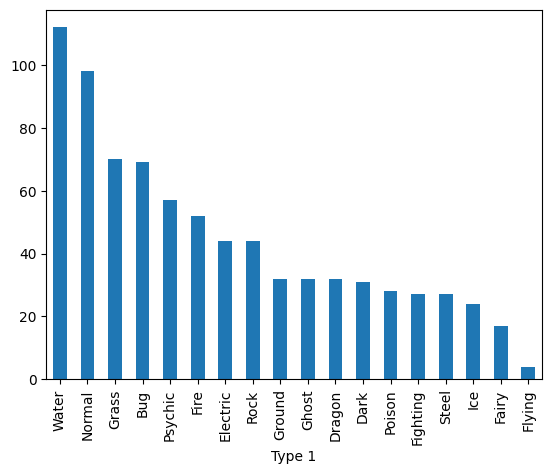

In [4]:
data['Type 1'].value_counts().plot.bar()

<Axes: xlabel='Type 2'>

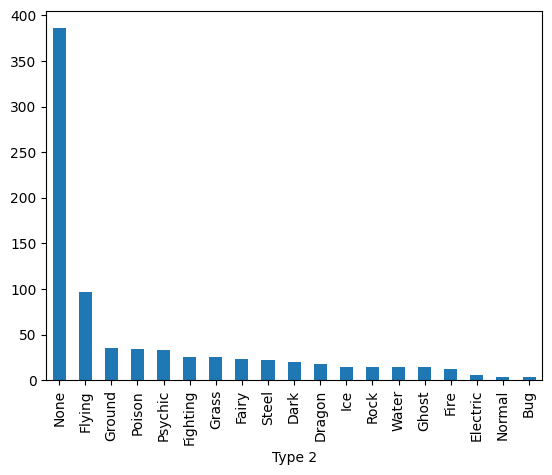

In [5]:
data['Type 2'].value_counts().plot.bar()

<Axes: xlabel='Legendary'>

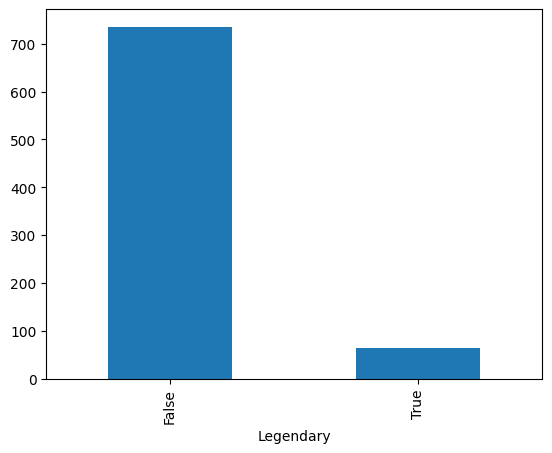

In [6]:
data['Legendary'].value_counts().plot.bar()

In [7]:
data['Type 1'].unique()
data['Type 2'].unique()

<StringArray>
[  'Poison',     'None',   'Flying',   'Dragon',   'Ground',    'Fairy',
    'Grass', 'Fighting',  'Psychic',    'Steel',      'Ice',     'Rock',
     'Dark',    'Water', 'Electric',     'Fire',    'Ghost',      'Bug',
   'Normal']
Length: 19, dtype: str

In [8]:
lb = LabelEncoder()
data['Legendary'] = lb.fit_transform(data['Legendary'])

data.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,0
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,0
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,0
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,0
4,4,Charmander,Fire,None,39,52,43,60,50,65,1,0


In [9]:
data.drop('Name',axis=1,inplace=True)

In [10]:
data = pd.get_dummies(data)

data.shape

(800, 46)

In [11]:
y = data.pop(item='Legendary')
x=data
x_train,x_test,y_train,y_test = tts(x,y,test_size=0.2)

logreg = LogisticRegression(max_iter=801)
logreg.fit(x_train,y_train)

ypred1 = logreg.predict(x_test)
accuracy_score(y_test,ypred1)

c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 801 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=801).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.925

In [12]:
error_rates = []
for a in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=a)
    knn.fit(x_train,y_train)
    preds = knn.predict(x_test)
    error_rates.append(np.mean(y_test-preds))

Text(0.5, 0, 'K value')

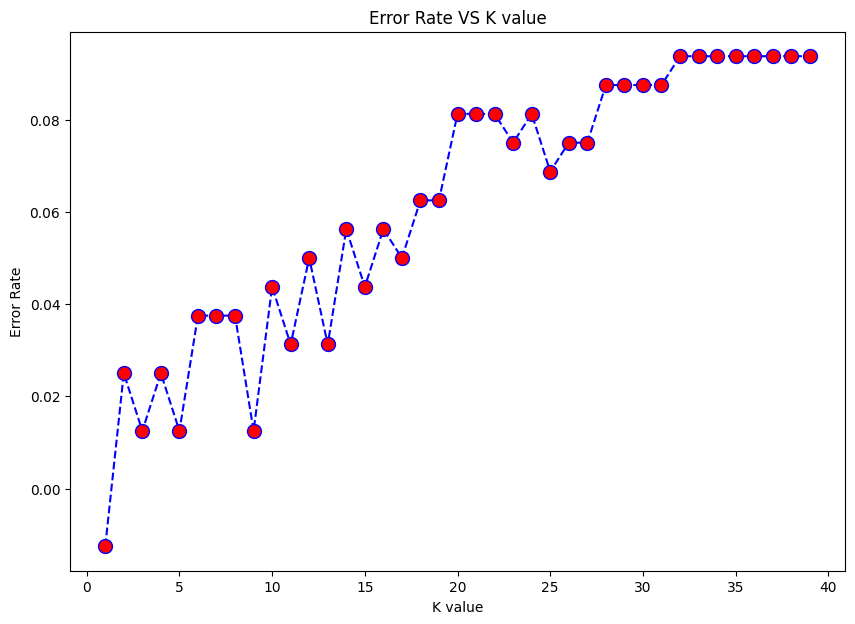

In [13]:
plt.figure(figsize=(10,7))
plt.plot(range(1,40),error_rates,color='blue',linestyle='dashed',marker='o',markerfacecolor='red',markersize=10)
plt.title('Error Rate VS K value')
plt.ylabel('Error Rate')
plt.xlabel('K value')

In [17]:
def accuracy_perc():
    num = accuracy_score(y_test,y_pred)
    num = round(num,2)
    return str(int(num*100))+'%'

knn_model = KNeighborsClassifier(n_neighbors=8)
knn_model.fit(x_train,y_train)
y_pred = knn_model.predict(x_test)
accuracy_perc()

'93%'

In [18]:
clf_model = DecisionTreeClassifier()
clf_model.fit(x_train,y_train)

y_pred = clf_model.predict(x_test)
accuracy_perc()

'89%'